# Pruebas de precisión del motor de decisión

Notebook de exploración rápida — **no forma parte del pipeline oficial** (no lo lee
`app.py` ni ningún otro notebook). Sirve para comparar, sobre el intervalo de fechas
que tú elijas, qué tan bien le habría ido a cada método de umbral del motor de
decisión (`fijo`, `rodante`, `banda`, y un método experimental `híbrido`).

**Cómo usarlo:** edita la celda de **Parámetros** (horizonte, rol, fecha de inicio
y fin) y vuelve a correr todo el notebook (`Kernel → Restart & Run All`).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Misma convencion que el resto de notebooks del proyecto: agregar src/ al path.
RAIZ = Path.cwd()
while not (RAIZ / "src" / "motor_decision.py").exists():
    if RAIZ.parent == RAIZ:
        raise FileNotFoundError("No encontre src/motor_decision.py subiendo desde el directorio actual.")
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from motor_decision import (
    cargar_fuente_pronostico, generar_senales, evaluar_backtest, umbrales_rodantes,
)

print("Raiz del proyecto:", RAIZ)


Raiz del proyecto: c:\Users\rafad\Downloads\Proyecto_Final\xm-spot-price-predictor


## Parámetros

Cambia estos valores y vuelve a correr el notebook.

In [2]:
HORIZONTE = "24h"          # "24h" o "72h"
ROL = "generador"          # "generador" o "comercializador"
FECHA_INICIO = "2026-07-07"   # inclusive
FECHA_FIN = "2026-08-05"      # inclusive
INCLUIR_HIBRIDO = True     # metodo experimental: umbral rodante + filtro de confianza de banda

# Parametros finos del motor (los mismos que usa src/motor_decision.py por defecto)
P_BAJO, P_ALTO = 25, 75
VENTANA_RODANTE_DIAS = 30
PERCENTIL_ANCHO_BANDA = 75

# Potencia asumida del cliente (generador o comercializador), en VATIOS.
# VALOR DE EJEMPLO -- no viene de ningun cliente real todavia, es solo para
# traducir "COP/kWh de ventaja" a "cuantos pesos gana o pierde" en un caso
# concreto. Cambialo por la potencia real cuando la tengas.
POTENCIA_W = 100_000  # 100 kW -- ejemplo de un cliente comercial/industrial pequeno
POTENCIA_KW = POTENCIA_W / 1000

## Carga de datos

Se carga la serie **completa** del horizonte elegido (no solo el intervalo) porque
el método `rodante` necesita historia continua para calcular su umbral móvil — cortar
la serie antes de este paso daría un resultado incorrecto para ese método. El
intervalo elegido se aplica **después**, solo para medir el resultado.

In [3]:
precio_hist = pd.read_csv(
    RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv", usecols=["precio_bolsa"]
)["precio_bolsa"].values

bandas, meta = cargar_fuente_pronostico(RAIZ, HORIZONTE)
print(f"Modelo activo ({HORIZONTE}): {meta.get('modelo')}")
print(f"Rango disponible: {bandas['fecha_hora'].min()} a {bandas['fecha_hora'].max()}")

inicio = pd.Timestamp(FECHA_INICIO)
fin = pd.Timestamp(FECHA_FIN) + pd.Timedelta(hours=23)
if inicio < bandas["fecha_hora"].min() or fin > bandas["fecha_hora"].max():
    print("\u26a0 Aviso: el intervalo pedido se sale del rango disponible -- se recorta a lo que hay.")
mascara_intervalo = (bandas["fecha_hora"] >= inicio) & (bandas["fecha_hora"] <= fin)
n_horas = int(mascara_intervalo.sum())
print(f"Horas en el intervalo elegido: {n_horas}")
if n_horas == 0:
    raise ValueError("El intervalo elegido no tiene ninguna hora de datos -- revisa FECHA_INICIO/FECHA_FIN.")


[validar_contrato_pronostico] advertencia: c:\Users\rafad\Downloads\Proyecto_Final\xm-spot-price-predictor\data\processed\resultados\pronostico_con_bandas_2026_adaptativo.csv tiene 2 fila(s) con cuantiles cruzados (q10>q50 o q50>q90) de 5208 totales -- revisar si crece en un modelo nuevo, probablemente borde de calibración.
Modelo activo (24h): N-BEATSx + calibracion conforme adaptativa (CQR, ventana movil 30 dias)
Rango disponible: 2026-01-01 00:00:00 a 2026-08-05 23:00:00
Horas en el intervalo elegido: 720


## Precisión del pronóstico en el intervalo (no depende del método)

Cobertura = % de horas donde el precio real cayó dentro de la banda `[q10,q90]`.
MAE = error absoluto promedio de `q50` frente al precio real. Estos dos números son
del **pronóstico**, no del motor de decisión -- son iguales para los 4 métodos de
abajo, se muestran aparte como contexto.

In [4]:
sub = bandas[mascara_intervalo]
cobertura_pct = ((sub["real"] >= sub["q10"]) & (sub["real"] <= sub["q90"])).mean() * 100
mae = (sub["real"] - sub["q50"]).abs().mean()
ancho_prom = (sub["q90"] - sub["q10"]).mean()

print(f"Cobertura del pronostico en el intervalo: {cobertura_pct:.1f}%  (objetivo: {meta.get('cobertura_objetivo_pct', 80)}%)")
print(f"MAE (|real - q50|):                        {mae:.1f} COP/kWh")
print(f"Ancho de banda promedio (q90-q10):          {ancho_prom:.1f} COP/kWh")


Cobertura del pronostico en el intervalo: 73.2%  (objetivo: 80%)
MAE (|real - q50|):                        93.6 COP/kWh
Ancho de banda promedio (q90-q10):          242.4 COP/kWh


## Traducción a pesos (COP)

`ventaja_cop_kwh` es una **tasa** (COP por cada kWh) — no dice cuánta plata es en
la práctica sin saber cuánta energía mueve el cliente. Se traduce a un monto total
asumiendo una potencia de cliente constante (`POTENCIA_W`, editable en Parámetros):

```
ganancia_perdida_cop = ventaja_cop_kwh × horas_de_acción × potencia_kW
```

**Esto es ilustrativo, no una simulación de portafolio real** — asume que el cliente
opera a potencia constante durante cada hora en que el motor marca una acción; no
modela contratos ya firmados, curva de carga real, ni si el cliente puede actuar
en la práctica en esa hora exacta (misma limitación ya documentada para el
backtest del motor en `docs/motor_decision_guia.md`).

## Precisión del motor de decisión por método

`hibrido` es un método oficial de `src/motor_decision.py` (umbral rodante + el
filtro de "esperar si la banda es ancha" que también usa `banda`) — se puede
desactivar en Parámetros con `INCLUIR_HIBRIDO = False` si solo quieres los 3
métodos originales.

In [5]:
metodos = ["fijo", "rodante", "banda"]
if INCLUIR_HIBRIDO:
    metodos.append("hibrido")

filas = []
for metodo in metodos:
    senal_full = generar_senales(
        bandas, metodo, ROL, precio_hist,
        p_bajo=P_BAJO, p_alto=P_ALTO,
        ventana_dias=VENTANA_RODANTE_DIAS, percentil_ancho_filtro=PERCENTIL_ANCHO_BANDA,
    )
    df_con_senal = bandas.assign(senal=senal_full)
    bt = evaluar_backtest(df_con_senal[mascara_intervalo], df_con_senal.loc[mascara_intervalo, "senal"], ROL)
    valido_freq = not np.isnan(bt["frecuencia_accion"]) and 0.10 <= bt["frecuencia_accion"] <= 0.40
    filas.append({
        "metodo": metodo,
        "ventaja_cop_kwh": bt["ventaja_cop_kwh"],
        "frecuencia_pct": bt["frecuencia_accion"] * 100,
        "horas_accion": bt["horas_accion"],
        "frecuencia_valida_10_40pct": valido_freq,
    })

tabla = pd.DataFrame(filas).set_index("metodo")

# Traduccion a pesos: COP/kWh de ventaja x horas de accion x potencia (kW) = COP totales.
# Supone que el cliente opera a potencia constante (POTENCIA_W) durante cada hora
# en que el motor marca una accion -- es una traduccion ilustrativa, NO una
# simulacion de portafolio real (no considera contratos, curva de carga real,
# ni si el cliente realmente puede actuar cada una de esas horas).
tabla["ganancia_perdida_cop"] = tabla["ventaja_cop_kwh"] * tabla["horas_accion"] * POTENCIA_KW

print(f"Supuesto: cliente con potencia constante de {POTENCIA_W:,.0f} W ({POTENCIA_KW:.0f} kW) durante las horas de accion.".replace(",", "."))
tabla

Supuesto: cliente con potencia constante de 100.000 W (100 kW) durante las horas de accion.


,ventaja_cop_kwh,frecuencia_pct,horas_accion,frecuencia_valida_10_40pct,ganancia_perdida_cop
metodo,,,,,
fijo,0.000000,100.000000,720,False,0.000000e+00
rodante,80.516871,50.555556,364,False,2.930814e+06
banda,-16.785111,53.472222,385,False,-6.462268e+05
hibrido,58.825305,25.138889,181,True,1.064738e+06


## Gráfica: ganancia o pérdida total en pesos, por método

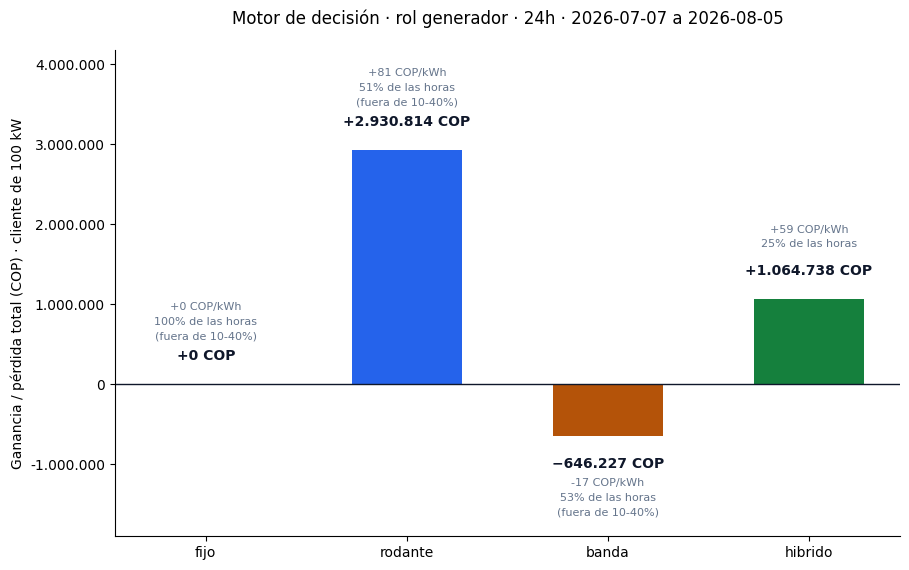

In [6]:
def fmt_cop(v):
    return f"{v:,.0f}".replace(",", ".")


valores_plot = tabla["ganancia_perdida_cop"].fillna(0)

# El ancho de la figura crece un poco si hay mas metodos (ej. al activar el hibrido) --
# mas ancho por columna que antes, porque el texto de detalle puede ser largo.
ancho_fig = max(8.5, 2.3 * len(tabla))
fig, ax = plt.subplots(figsize=(ancho_fig, 5.8))

colores = {"fijo": "#64748B", "rodante": "#2563EB", "banda": "#B45309", "hibrido": "#15803D"}
barras = ax.bar(tabla.index, valores_plot, color=[colores.get(m, "#94A3B8") for m in tabla.index], width=0.55)

ax.axhline(0, color="#0F172A", linewidth=1)
ax.set_ylabel(f"Ganancia / p\u00e9rdida total (COP) \u00b7 cliente de {POTENCIA_KW:.0f} kW")
ax.set_title(f"Motor de decisi\u00f3n \u00b7 rol {ROL} \u00b7 {HORIZONTE} \u00b7 {FECHA_INICIO} a {FECHA_FIN}", pad=18)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_cop(x)))

# El eje Y se reajusta segun el rango REAL de ganancia/perdida de este intervalo.
# El margen minimo se calcula como fraccion de la ESCALA de los datos (no un
# numero fijo en COP) -- un piso fijo como "20" tenia sentido cuando se
# graficaba la tasa COP/kWh (decenas), pero es invisible ahora que se grafica
# el total en pesos (puede ser millones).
y_min = min(0, float(valores_plot.min()))
y_max = max(0, float(valores_plot.max()))
rango = y_max - y_min
escala = max(abs(y_min), abs(y_max), 1.0)
margen = max(rango * 0.35, escala * 0.25)
ax.set_ylim(y_min - margen, y_max + margen)

# Las etiquetas se ubican como FRACCION DEL MARGEN ya reservado (coordenadas de
# datos, no "offset points") -- quedan garantizadas dentro de ylim sin importar
# el DPI, y el detalle se parte en hasta 2 lineas para no invadir la columna
# vecina cuando el texto es largo y las barras quedan juntas.
for barra, (metodo, fila) in zip(barras, tabla.iterrows()):
    freq = fila["frecuencia_pct"]
    ventaja = fila["ventaja_cop_kwh"]
    total_cop = fila["ganancia_perdida_cop"]
    y = 0 if np.isnan(total_cop) else total_cop
    signo_dir = 1 if y >= 0 else -1
    x_centro = barra.get_x() + barra.get_width() / 2

    if np.isnan(total_cop):
        valor_pesos = "sin datos"
    else:
        signo = "+" if total_cop >= 0 else "\u2212"
        valor_pesos = f"{signo}{fmt_cop(abs(total_cop))} COP"
    ax.annotate(valor_pesos, (x_centro, y + margen * 0.28 * signo_dir),
                ha="center", va="center", fontsize=10, fontweight="bold", color="#0F172A")

    if np.isnan(ventaja):
        lineas_detalle = ["sin acciones"]
    else:
        lineas_detalle = [f"{ventaja:+.0f} COP/kWh", f"{freq:.0f}% de las horas"]
    if not fila["frecuencia_valida_10_40pct"]:
        lineas_detalle.append("(fuera de 10-40%)")
    detalle = "\n".join(lineas_detalle)
    ax.annotate(detalle, (x_centro, y + margen * 0.62 * signo_dir),
                ha="center", va="center", fontsize=8, color="#64748B", linespacing=1.6)

plt.tight_layout()
plt.show()

**Cómo leerlo:** una barra por encima de 0 significa que seguir esa señal en este
intervalo habría dado, en promedio, un precio mejor que el promedio general del
periodo; por debajo de 0 significa que habría sido peor que no hacer nada. La
etiqueta sobre cada barra dice qué tan seguido actuó esa regla — una ventaja alta con
muy pocas horas de acción (o fuera del rango 10-40%) es un resultado poco confiable,
no una señal fuerte.

## Tabla resumen: ganancia o pérdida total por método

In [7]:
from IPython.display import Markdown, display

filas_md = ["| M\u00e9todo | Ganancia / p\u00e9rdida total | COP/kWh | Frecuencia de acci\u00f3n | \u00bfV\u00e1lida? |",
            "|---|---|---|---|---|"]
for metodo, fila in tabla.sort_values("ganancia_perdida_cop", ascending=False, na_position="last").iterrows():
    total = fila["ganancia_perdida_cop"]
    ventaja = fila["ventaja_cop_kwh"]
    if np.isnan(total):
        total_txt, tasa_txt = "sin datos", "sin datos"
    else:
        signo = "+" if total >= 0 else "\u2212"
        total_txt = f"**{signo}{fmt_cop(abs(total))} COP**"
        tasa_txt = f"{ventaja:+.0f} COP/kWh"
    freq_txt = f"{fila['frecuencia_pct']:.0f}% ({fila['horas_accion']} horas)"
    valida_txt = "\u2705 s\u00ed" if fila["frecuencia_valida_10_40pct"] else "\u26a0\ufe0f fuera de 10-40%"
    filas_md.append(f"| {metodo} | {total_txt} | {tasa_txt} | {freq_txt} | {valida_txt} |")

display(Markdown(
    f"**Cliente de ejemplo: {POTENCIA_KW:.0f} kW \u00b7 {ROL} \u00b7 {HORIZONTE} \u00b7 {FECHA_INICIO} a {FECHA_FIN}**\n\n"
    + "\n".join(filas_md)
))

**Cliente de ejemplo: 100 kW · generador · 24h · 2026-07-07 a 2026-08-05**

| Método | Ganancia / pérdida total | COP/kWh | Frecuencia de acción | ¿Válida? |
|---|---|---|---|---|
| rodante | **+2.930.814 COP** | +81 COP/kWh | 51% (364 horas) | ⚠️ fuera de 10-40% |
| hibrido | **+1.064.738 COP** | +59 COP/kWh | 25% (181 horas) | ✅ sí |
| fijo | **+0 COP** | +0 COP/kWh | 100% (720 horas) | ⚠️ fuera de 10-40% |
| banda | **−646.227 COP** | -17 COP/kWh | 53% (385 horas) | ⚠️ fuera de 10-40% |